# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [162]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
#from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt 

from sklearn.utils import resample
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from sklearn import metrics
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt 

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [31]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"

colnames = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

#Load the file from local directory using pd.read_csv which is a special form of read_table
#while reading the data, supply the "colnames" list

pima_df = pd.read_csv("pima-indians-diabetes.data", names= colnames)

In [9]:
pima_df.head(5).T

,0,1,2,3,4
preg,6.000,1.000,8.000,1.000,0.000
plas,148.000,85.000,183.000,89.000,137.000
pres,72.000,66.000,64.000,66.000,40.000
skin,35.000,29.000,0.000,23.000,35.000
test,0.000,0.000,0.000,94.000,168.000
mass,33.600,26.600,23.300,28.100,43.100
pedi,0.627,0.351,0.672,0.167,2.288
age,50.000,31.000,32.000,21.000,33.000
class,1.000,0.000,1.000,0.000,1.000


In [10]:
#Lets analysze the distribution of the various attributes
pima_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
test,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
class,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [11]:
pima_df.head(10)

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [14]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
plas     768 non-null int64
pres     768 non-null int64
skin     768 non-null int64
test     768 non-null int64
mass     768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
pima_df.shape

(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [17]:
pima_df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [40]:
pima_df['plas'].replace(0,pima_df['plas'].mean(),inplace=True) 
pima_df['pres'].replace(0,pima_df['pres'].mean(),inplace=True) 
pima_df['skin'].replace(0,pima_df['skin'].mean(),inplace=True) 
pima_df['test'].replace(0,pima_df['test'].mean(),inplace=True) 
pima_df['mass'].replace(0,pima_df['mass'].mean(),inplace=True) 

# Q5 Print the descriptive statistics of each & every column using describe() function

In [42]:
pima_df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

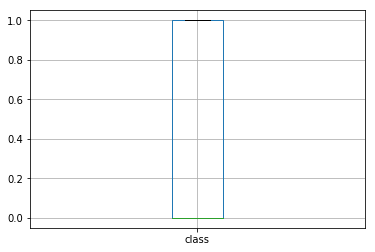

In [45]:
pima_df.boxplot(column='class')

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

C:\Users\Admin\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


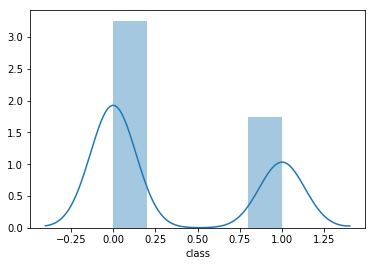

In [48]:
sns.distplot(pima_df['class'])

##### Ans. With the above Histogram and Boxplot we understand that this 'class' is a categorical column in this dataset is the resultant column of the patient regarding a patient has diabetes or not. It is either 0 and 1.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


Using the plot - infer the relationship between different variables

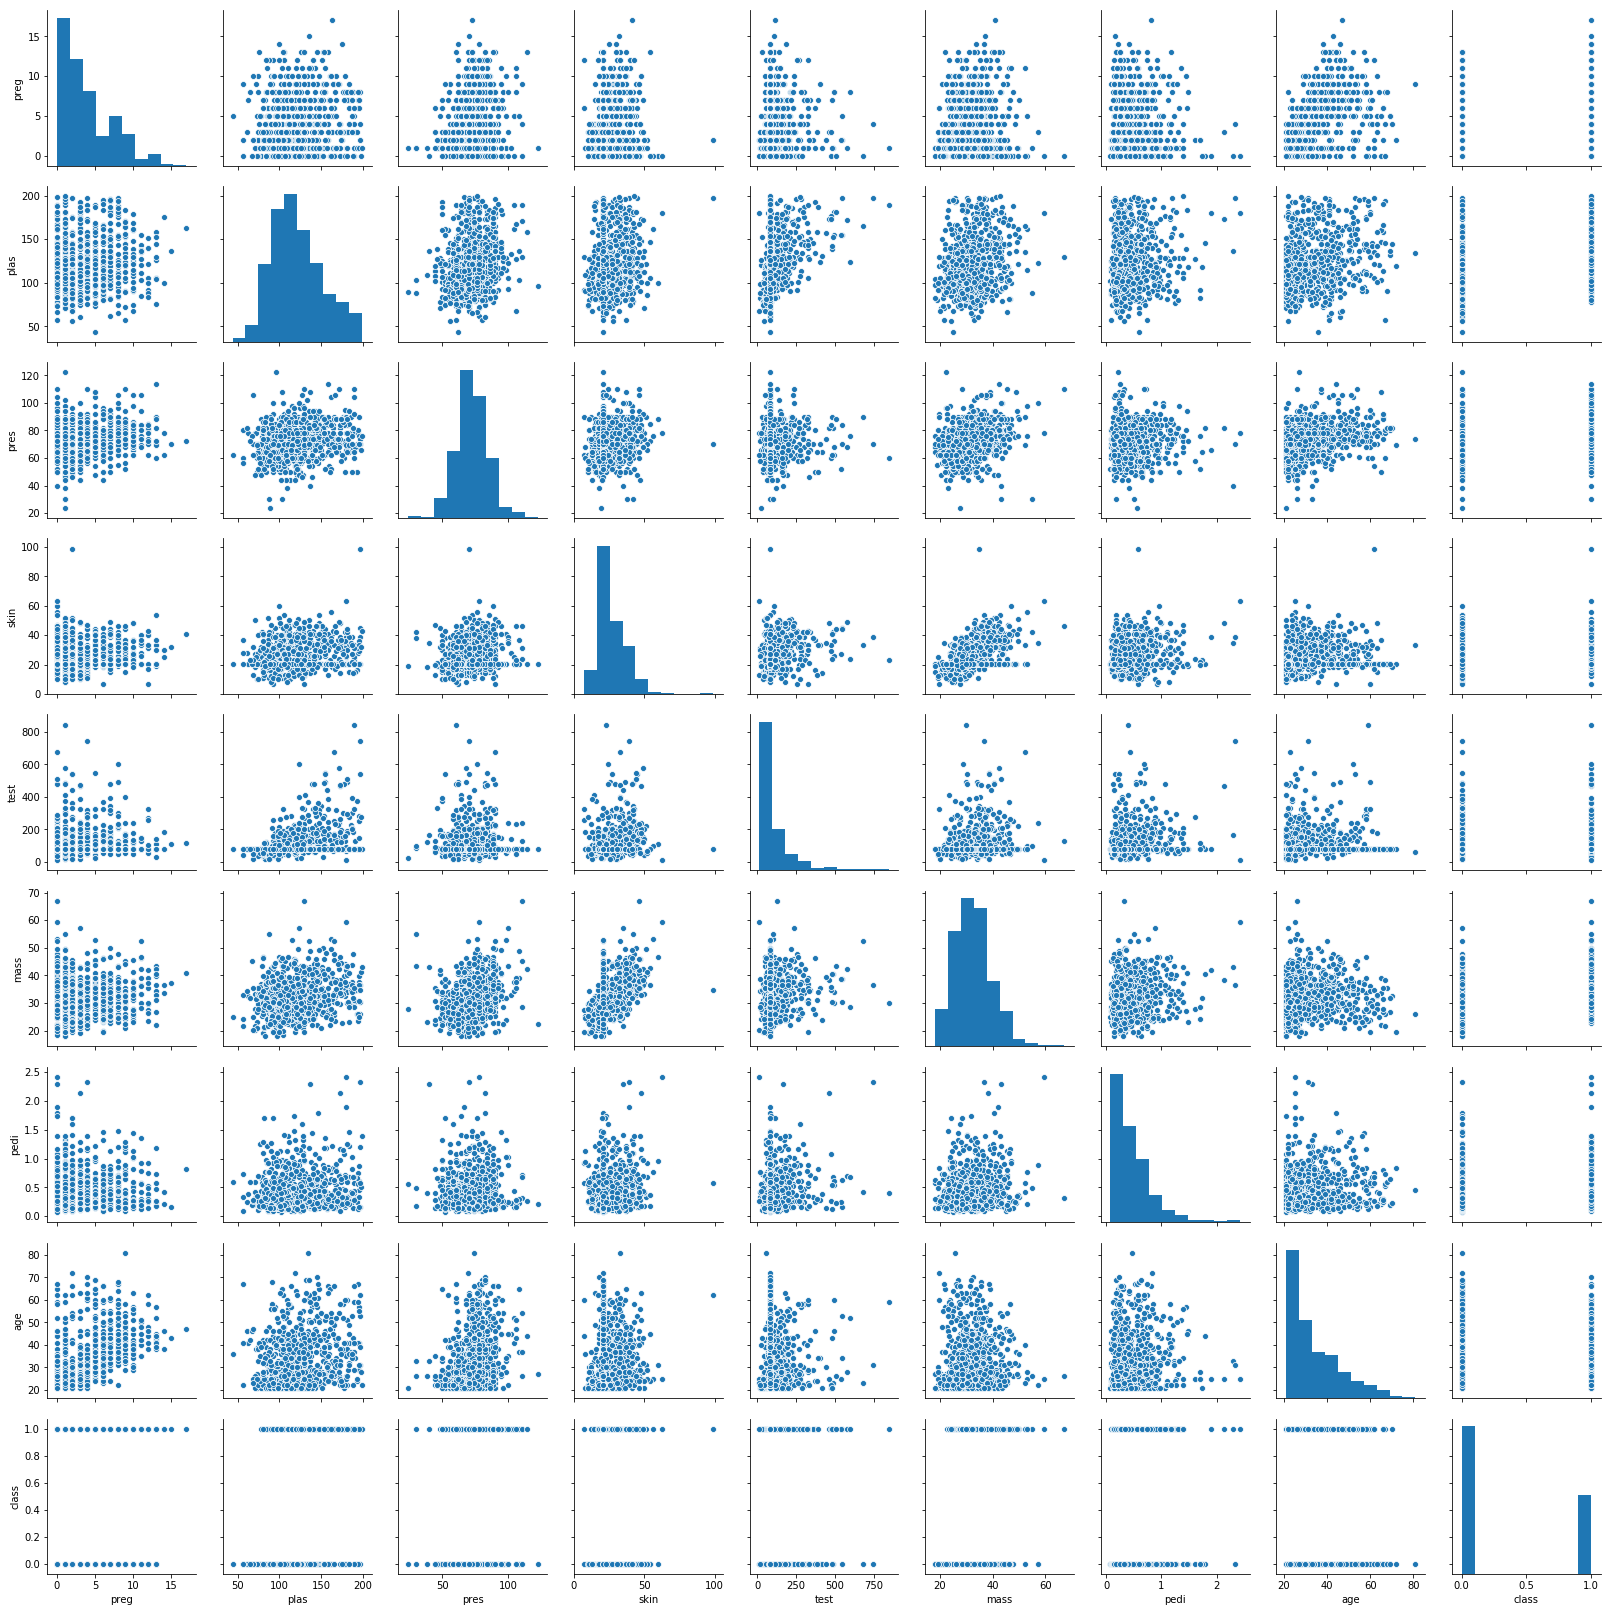

In [47]:
sns.pairplot(pima_df)

In [49]:
corr = pima_df.corr()
corr

,preg,plas,pres,skin,test,mass,pedi,age,class
preg,1.000000,0.127964,0.208984,0.013376,-0.018082,0.021546,-0.033523,0.544341,0.221898
plas,0.127964,1.000000,0.219666,0.160766,0.396597,0.231478,0.137106,0.266600,0.492908
pres,0.208984,0.219666,1.000000,0.134155,0.010926,0.281231,0.000371,0.326740,0.162986
skin,0.013376,0.160766,0.134155,1.000000,0.240361,0.535703,0.154961,0.026423,0.175026
test,-0.018082,0.396597,0.010926,0.240361,1.000000,0.189856,0.157806,0.038652,0.179185
mass,0.021546,0.231478,0.281231,0.535703,0.189856,1.000000,0.153508,0.025748,0.312254
pedi,-0.033523,0.137106,0.000371,0.154961,0.157806,0.153508,1.000000,0.033561,0.173844
age,0.544341,0.266600,0.326740,0.026423,0.038652,0.025748,0.033561,1.000000,0.238356
class,0.221898,0.492908,0.162986,0.175026,0.179185,0.312254,0.173844,0.238356,1.000000


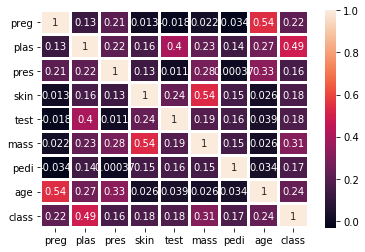

In [54]:
sns.heatmap(corr, annot=True, linewidths = 2 )

#### Ans) With the above correlation matrix we conclude that Class column i.e. Having Diabetes has 
High relation with Plasma Glucose  & BMI

Low relation with Blood Pressure & Diabetes Pedigree

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [55]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]

In [56]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [78]:
model=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [79]:
ypred=model.predict(X_test)

In [80]:
acc1=metrics.accuracy_score(y_test,ypred)
print(acc1)

0.7316017316017316


In [81]:
cm=metrics.confusion_matrix(y_test,ypred)
print(cm)

[[106  41]
 [ 21  63]]


In [83]:
cr=metrics.classification_report(y_test,ypred)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       147
           1       0.61      0.75      0.67        84

   micro avg       0.73      0.73      0.73       231
   macro avg       0.72      0.74      0.72       231
weighted avg       0.75      0.73      0.74       231



In [85]:

print (pd.DataFrame(model.feature_importances_, columns = ["Imp"], index = X_train.columns))

           Imp
preg  0.028172
plas  0.507051
pres  0.000000
skin  0.016898
test  0.000000
mass  0.250059
pedi  0.051113
age   0.146708


In [87]:
#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(model,parameter,cv=3)
GS.fit(X,y)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [89]:
GS.score(X_test,y_test)

0.7662337662337663

In [91]:
gs_pred=GS.predict(X_test)

In [92]:
metrics.accuracy_score(y_test,gs_pred)

0.7662337662337663

In [93]:
GS.best_params_

{'criterion': 'entropy', 'max_depth': 3}

In [95]:
model2=DecisionTreeClassifier(criterion = 'entropy',max_depth=4,random_state=0)
model2.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [96]:
ypred2=model2.predict(X_test)

# Q10 Print the accuracy of the model & print the confusion matrix 

In [98]:
acc2=metrics.accuracy_score(y_test,ypred2)
print(acc2)

0.7316017316017316


In [100]:
cm2=metrics.confusion_matrix(y_test,ypred2)
print(cm2)

[[106  41]
 [ 21  63]]


In [102]:
cr2=metrics.classification_report(y_test,ypred2)
print(cr2)

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       147
           1       0.61      0.75      0.67        84

   micro avg       0.73      0.73      0.73       231
   macro avg       0.72      0.74      0.72       231
weighted avg       0.75      0.73      0.74       231



Print the feature importance of the decision model - Optional

Ans) The most important feature of Decision is F1 score of 0.72,  since it is harmonic mean function of Precision and Recall both.

# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [118]:
Dt_model=DecisionTreeClassifier(criterion='entropy',random_state=0)

In [119]:
Dt_model2=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)

In [120]:
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=0 )

In [123]:
models = []
models.append(('DecisionTree', Dt_model))
models.append(('RandomForest', Rf_model))

DecisionTree: 0.580115 (0.000786)
RandomForest: 0.595151 (0.002701)


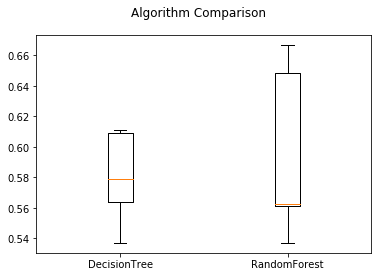

In [124]:
# evaluate each model in turn
results = []
names = []
scoring = 'recall'
for name, model in models:
	kfold = model_selection.KFold(n_splits=5,random_state=2)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

#Below Result :  DecisionTree: 0.562904 (0.004411)
#                               Recall   Precision

In [125]:
results

[array([0.53703704, 0.609375  , 0.57894737, 0.56410256, 0.61111111]),
 array([0.64814815, 0.5625    , 0.56140351, 0.66666667, 0.53703704])]

# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [131]:
#Applying Adaboost to RandomForest
sc=StandardScaler()
X=sc.fit_transform(X)

In [132]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
base_rf=RandomForestClassifier(n_estimators=101,random_state=2)

In [135]:
boost_rf=AdaBoostClassifier(base_estimator=base_rf,n_estimators=50,random_state=2)

In [139]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=2)
for model, name in zip([base_rf], ['RF']):
    k=0
    recall=np.zeros((2,5))
    prec=np.zeros((2,5))
    fscore=np.zeros((2,5))
    for train,test in kf.split(X,y):
        X_train,X_test=X[train,:],X[test,:]
        y_train,y_test=y[train],y[test]
        model.fit(X_train,y_train)
        Y_predict=model.predict(X_test)
        cm=metrics.confusion_matrix(y_test,Y_predict)
        for i in np.arange(0,2):
            recall[i,k]=cm[i,i]/cm[i,:].sum()
        for i in np.arange(0,2):
            prec[i,k]=cm[i,i]/cm[:,i].sum()
        k=k+1
    for row in np.arange(0,2):
        for col in np.arange(0,5):
            fscore[row,col]=2*(recall[row,col]*prec[row,col])/(recall[row,col]+prec[row,col])
    print("f1_weighted for Healthy: %0.02f (+/- %0.5f) [%s]" % (np.mean(fscore[0,:]), np.var(fscore[0,:],ddof=1), name ))   
    print("f1_weighted for Diabetic: %0.02f (+/- %0.5f) [%s]" % (np.mean(fscore[1,:]), np.var(fscore[1,:],ddof=1), name ))   
    

f1_weighted for Healthy: 0.82 (+/- 0.00042) [RF]
f1_weighted for Diabetic: 0.65 (+/- 0.00059) [RF]


In [143]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve, auc
kf=KFold(n_splits=5,shuffle=True,random_state=2)
for model, name in zip([base_rf], ['RF']):
    roc_auc=[]
    for train,test in kf.split(X,y):
        X_train,X_test=X[train,:],X[test,:]
        y_train,y_test=y[train],y[test]
        model.fit(X_train,y_train)
        Y_predict=model.predict(X_test)
        cm=metrics.confusion_matrix(y_test,Y_predict)
        fpr,tpr, _ = roc_curve(y_test,Y_predict)
        roc_auc.append(auc(fpr, tpr))
    print("AUC scores: %0.02f (+/- %0.5f) [%s]" % (np.mean(roc_auc), np.var(roc_auc,ddof=1), name ))   
    

AUC scores: 0.73 (+/- 0.00037) [RF]


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [146]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn import metrics
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt 

In [147]:
sc=StandardScaler()
X_std=sc.fit_transform(X)

In [148]:
cov_matrix = np.cov(X_std.T)
#print('Covariance Matrix \n%s', cov_matrix)

In [149]:
cov_matrix.shape

(8, 8)

In [150]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

In [151]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 27.60603168  47.88959561  61.5847034   72.8623829   82.60734565
  89.37219839  95.09022226 100.        ]


In [152]:
eig_vec_sliced=eig_vecs[0:11].transpose()

In [153]:
eig_vec_sliced.shape

(8, 8)

In [154]:
X_std.shape

(768, 8)

In [155]:
x_new=np.dot(X_std,eig_vec_sliced)
x_new.shape

(768, 8)

In [156]:
Dt_model=DecisionTreeClassifier(criterion='gini',random_state=0)#fully grown tree (high bias error and var error)

In [158]:
from sklearn.ensemble import BaggingClassifier
Bagged_DT=BaggingClassifier(n_estimators=51,random_state=0)

In [159]:
models = []
models.append(('DecisionTree', Dt_model))

In [172]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=2)
for model, name in zip([Dt_model ], ['DT']):
    k=0
    recall=np.zeros((3,5))
    prec=np.zeros((3,5))
    fscore=np.zeros((3,5))
    for train,test in kf.split(X,y):
        X_train,X_test=X[train,:],X[test,:]
        y_train,y_test=y[train],y[test]
        model.fit(X_train,y_train)
        Y_predict=model.predict(X_test)
        #acc.append(metrics.accuracy_score(Ytest,Y_predict))
        cm=metrics.confusion_matrix(y_test,Y_predict)
        for i in np.arange(0,1):
            recall[i,k]=cm[i,i]/cm[i,:].sum()
        for i in np.arange(0,1):
            prec[i,k]=cm[i,i]/cm[:,i].sum()
        k=k+1
    for row in np.arange(0,3):
        for col in np.arange(0,5):
            fscore[row,col]=2*(recall[row,col]*prec[row,col])/(recall[row,col]+prec[row,col])
    print("f1_weighted for class1: %0.02f (+/- %0.5f) [%s]" % (np.mean(fscore[0,:]), np.var(fscore[0,:],ddof=1), name ))   
    

f1_weighted for class1: 0.75 (+/- 0.00200) [DT]


C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in double_scalars


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.